In [10]:
import torch
import torch.nn as nn

# Shared (Unified Global) MLP model
class SharedEncoderModel(nn.Module):
    def __init__(self, numeric_dim, cat_cardinalities):
        super().__init__()
        self.numeric_dim = numeric_dim
        # Create embedding layers for each categorical feature
        self.embeddings = nn.ModuleList()
        self.emb_dims = []
        for card in cat_cardinalities:
            emb_dim = min(50, (card + 1) // 2)  # e.g. 86 categories -> 43-dim embedding (capped at 50)
            self.emb_dims.append(emb_dim)
            self.embeddings.append(nn.Embedding(num_embeddings=card, embedding_dim=emb_dim))
        # Define MLP layers
        total_input = numeric_dim + sum(self.emb_dims)  # total input size after concatenation
        self.layer1 = nn.Linear(total_input, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        # Activation and dropout layers
        self.relu = nn.ReLU()
        self.drop1 = nn.Dropout(0.2)
        self.drop2 = nn.Dropout(0.2)
        self.drop3 = nn.Dropout(0.2)
    def forward(self, numeric_x, cat_x):
        # Embed each categorical feature and concatenate
        embedded_feats = []
        for j, emb_layer in enumerate(self.embeddings):
            emb = emb_layer(cat_x[:, j])        # shape: (batch, emb_dims[j])
            embedded_feats.append(emb)
        # Concatenate numeric and all embedded categorical features
        if embedded_feats:
            x = torch.cat([numeric_x] + embedded_feats, dim=1)
        else:
            x = numeric_x
        # Forward pass through hidden layers
        x = self.relu(self.layer1(x))
        x = self.drop1(x)
        x = self.relu(self.layer2(x))
        x = self.drop2(x)
        x = self.relu(self.layer3(x))
        x = self.drop3(x)
        return self.output(x)  # output shape: (batch, 1)


In [11]:
# Grouped (Hierarchical Modular) MLP model
class GroupedEncoderModel(nn.Module):
    def __init__(self, numeric_idx_groups, cat_idx_groups, cat_card_groups):
        super().__init__()
        # --- Financial group ---
        fin_num_in = len(numeric_idx_groups['financial'])  # e.g. 3 numeric features
        # Financial encoder: 3 -> 32 -> 16
        self.fin_fc1 = nn.Linear(fin_num_in, 32)
        self.fin_fc2 = nn.Linear(32, 16)
        # --- Creative/Cast group ---
        self.cre_embeddings = nn.ModuleList()
        for card in cat_card_groups['creative']:
            emb_dim = min(50, (card + 1) // 2)
            self.cre_embeddings.append(nn.Embedding(num_embeddings=card, embedding_dim=emb_dim))
        cre_input_dim = sum([emb.embedding_dim for emb in self.cre_embeddings])  # e.g. ~139
        # Creative encoder MLP: 139 -> 128 -> 64
        self.cre_fc1 = nn.Linear(cre_input_dim, 128)
        self.cre_fc2 = nn.Linear(128, 64)
        # --- Metadata group ---
        self.met_embeddings = nn.ModuleList()
        for card in cat_card_groups['metadata']:
            emb_dim = min(50, (card + 1) // 2)
            self.met_embeddings.append(nn.Embedding(num_embeddings=card, embedding_dim=emb_dim))
        met_cat_input = sum([emb.embedding_dim for emb in self.met_embeddings])  # e.g. 64
        met_num_in = len(numeric_idx_groups['metadata'])                        # e.g. 1 (runtime)
        # Metadata encoder MLP: 65 -> 64 -> 32
        self.met_fc1 = nn.Linear(met_cat_input + met_num_in, 64)
        self.met_fc2 = nn.Linear(64, 32)
        # --- Fusion network ---
        fusion_input = 16 + 64 + 32  # concatenated bottlenecks
        self.fusion_fc1 = nn.Linear(fusion_input, 64)
        self.fusion_fc2 = nn.Linear(64, 32)
        self.fusion_out = nn.Linear(32, 1)
        # Shared activation & dropout layers
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.1)  # slightly lower dropout within groups
        # Save index mappings for forward slicing
        self.numeric_idx_groups = numeric_idx_groups
        self.cat_idx_groups = cat_idx_groups
    def forward(self, numeric_x, cat_x):
        # Financial features forward
        fin_nums = numeric_x[:, self.numeric_idx_groups['financial']]        # select [budget, votes, year]
        fin_h = self.relu(self.fin_fc1(fin_nums))
        fin_h = self.drop(fin_h)
        fin_h = self.fin_fc2(fin_h)  # (batch, 16) financial latent output
        # Creative features forward
        cre_embedded = []
        for i, emb_layer in enumerate(self.cre_embeddings):
            col_idx = self.cat_idx_groups['creative'][i]
            cre_embedded.append(emb_layer(cat_x[:, col_idx]))
        cre_input = torch.cat(cre_embedded, dim=1)                          # (batch, ~139)
        cre_h = self.relu(self.cre_fc1(cre_input))
        cre_h = self.drop(cre_h)
        cre_h = self.cre_fc2(cre_h)  # (batch, 64) creative latent output
        # Metadata features forward
        met_embedded = []
        for j, emb_layer in enumerate(self.met_embeddings):
            col_idx = self.cat_idx_groups['metadata'][j]
            met_embedded.append(emb_layer(cat_x[:, col_idx]))
        met_cat_vec = torch.cat(met_embedded, dim=1)                        # (batch, ~64)
        met_num_vec = numeric_x[:, self.numeric_idx_groups['metadata']]     # select [runtime]
        met_input = torch.cat([met_num_vec, met_cat_vec], dim=1)            # (batch, 65)
        met_h = self.relu(self.met_fc1(met_input))
        met_h = self.drop(met_h)
        met_h = self.met_fc2(met_h)      # (batch, 32) metadata latent output
        # Fusion of all groups
        fused = torch.cat([fin_h, cre_h, met_h], dim=1)  # (batch, 112)
        x = self.relu(self.fusion_fc1(fused))
        x = self.drop(x)
        x = self.relu(self.fusion_fc2(x))
        return self.fusion_out(x)      # (batch, 1)


In [12]:
import os
import numpy as np
import pandas as pd

ALL_FEATURES_DIR = "../data/processed/all_features"

train_path = os.path.join(ALL_FEATURES_DIR, "train.csv")
val_path   = os.path.join(ALL_FEATURES_DIR, "val.csv")
test_path  = os.path.join(ALL_FEATURES_DIR, "test.csv")
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)



# -----------------------------
# Columns (match your baseline)
# -----------------------------
TARGET_COL = "gross"  # predict log1p(gross)

NUMERIC_COLS = ["budget", "votes", "runtime", "year"]
CAT_COLS     = ["rating", "genre", "director", "writer", "star", "country", "company"]

# -----------------------------
# Categorical: rare grouping + label encoding (fit on train only)
# -----------------------------
def build_cat_vocab(train_series: pd.Series, min_freq=5):
    s = train_series.fillna("Unknown").astype(str)
    vc = s.value_counts()
    keep = set(vc[vc >= min_freq].index)
    s2 = s.where(s.isin(keep), "Other")

    vocab = {cat: i for i, cat in enumerate(sorted(s2.unique()))}
    # ensure required tokens exist
    if "Unknown" not in vocab:
        vocab["Unknown"] = len(vocab)
    if "Other" not in vocab:
        vocab["Other"] = len(vocab)

    return vocab, keep

def apply_cat_vocab(series: pd.Series, vocab: dict, keep: set):
    s = series.fillna("Unknown").astype(str)
    s = s.where(s.isin(keep), "Other")
    # unseen -> Unknown
    return s.map(lambda x: vocab.get(x, vocab["Unknown"])).astype(np.int64).values

cat_to_idx = {}
cat_keep = {}
for c in CAT_COLS:
    vocab, keep = build_cat_vocab(train_df[c], min_freq=5)
    cat_to_idx[c] = vocab
    cat_keep[c] = keep

# -----------------------------
# Numeric: log1p + standardize (fit on train only)
# -----------------------------
def fit_numeric_stats(df: pd.DataFrame, numeric_cols):
    df = df.copy()

    # log1p (same idea as baseline)
    df["budget"] = np.log1p(df["budget"].astype(float))
    df["votes"]  = np.log1p(df["votes"].astype(float))

    med = df[numeric_cols].median(numeric_only=True)
    df[numeric_cols] = df[numeric_cols].fillna(med)

    mean = df[numeric_cols].mean()
    std  = df[numeric_cols].std().replace(0, 1.0)
    return med, mean, std

def transform_numeric(df: pd.DataFrame, numeric_cols, med, mean, std):
    df = df.copy()
    df["budget"] = np.log1p(df["budget"].astype(float))
    df["votes"]  = np.log1p(df["votes"].astype(float))

    df[numeric_cols] = df[numeric_cols].fillna(med)
    X = (df[numeric_cols] - mean) / std
    return X.astype(np.float32).values

med, mean, std = fit_numeric_stats(train_df, NUMERIC_COLS)

# -----------------------------
# Build X arrays
# -----------------------------
X_train_num = transform_numeric(train_df, NUMERIC_COLS, med, mean, std)
X_val_num   = transform_numeric(val_df,   NUMERIC_COLS, med, mean, std)
X_test_num  = transform_numeric(test_df,  NUMERIC_COLS, med, mean, std)

X_train_cat = np.stack([apply_cat_vocab(train_df[c], cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)
X_val_cat   = np.stack([apply_cat_vocab(val_df[c],   cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)
X_test_cat  = np.stack([apply_cat_vocab(test_df[c],  cat_to_idx[c], cat_keep[c]) for c in CAT_COLS], axis=1)

# Targets (train/val only)
y_train = np.log1p(train_df[TARGET_COL].astype(float).values).astype(np.float32)
y_val   = np.log1p(val_df[TARGET_COL].astype(float).values).astype(np.float32)




In [13]:
# ============================================
# NEW CELL (place AFTER your preprocessing cell that defines:
# X_train_num, X_train_cat, y_train, X_val_num, X_val_cat, y_val, X_test_num, X_test_cat
# and also CAT_COLS, NUMERIC_COLS, cat_to_idx)
# ============================================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ---- sanity checks (fail fast) ----
required = ["X_train_num","X_train_cat","y_train","X_val_num","X_val_cat","y_val","X_test_num","X_test_cat","CAT_COLS","NUMERIC_COLS","cat_to_idx"]
missing = [v for v in required if v not in globals()]
assert not missing, f"Missing variables from preprocessing cell: {missing}"

# ---- device / seed ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def seed_everything(seed=42):
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)

# ---- tensors + loaders ----
X_train_num_t = torch.tensor(X_train_num, dtype=torch.float32)
X_train_cat_t = torch.tensor(X_train_cat, dtype=torch.long)
y_train_t     = torch.tensor(y_train, dtype=torch.float32)

X_val_num_t = torch.tensor(X_val_num, dtype=torch.float32)
X_val_cat_t = torch.tensor(X_val_cat, dtype=torch.long)
y_val_t     = torch.tensor(y_val, dtype=torch.float32)

BATCH_SIZE = 256
train_loader = DataLoader(
    TensorDataset(X_train_num_t, X_train_cat_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(X_val_num_t, X_val_cat_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0, pin_memory=True
)

# ---- build models (cat cardinalities from cat_to_idx) ----
cat_cardinalities = [len(cat_to_idx[c]) for c in CAT_COLS]
numeric_dim = X_train_num.shape[1]

global_model = SharedEncoderModel(numeric_dim, cat_cardinalities).to(device)

# build group indices SAFELY from column names (never hardcode)
num_idx = {c: i for i, c in enumerate(NUMERIC_COLS)}  # ["budget","votes","runtime","year"]
cat_idx = {c: i for i, c in enumerate(CAT_COLS)}      # ["rating","genre","director","writer","star","country","company"]

numeric_idx_groups = {
    "financial": [num_idx["budget"], num_idx["votes"], num_idx["year"]],  # [0,1,3]
    "metadata":  [num_idx["runtime"]],                                    # [2]
}
cat_idx_groups = {
    "creative": [cat_idx["director"], cat_idx["writer"], cat_idx["star"]],  # [2,3,4]
    "metadata": [cat_idx["rating"], cat_idx["genre"], cat_idx["country"], cat_idx["company"]],  # [0,1,5,6]
}
cat_card_groups = {
    "creative": [cat_cardinalities[i] for i in cat_idx_groups["creative"]],
    "metadata": [cat_cardinalities[i] for i in cat_idx_groups["metadata"]],
}

grouped_model = GroupedEncoderModel(
    numeric_idx_groups=numeric_idx_groups,
    cat_idx_groups=cat_idx_groups,
    cat_card_groups=cat_card_groups
).to(device)

# ---- params count ----
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Global params :", count_params(global_model))
print("Grouped params:", count_params(grouped_model))

# ---- loss / optimizer ----
criterion = nn.MSELoss()
opt_global  = torch.optim.AdamW(global_model.parameters(),  lr=1e-3, weight_decay=1e-4)
opt_grouped = torch.optim.AdamW(grouped_model.parameters(), lr=1e-3, weight_decay=1e-4)

# ---- metrics helpers ----
@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    for Xn, Xc, yb in loader:
        Xn = Xn.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        pred = model(Xn, Xc).squeeze(1)
        mse_sum += torch.sum((pred - yb) ** 2).item()
        mae_sum += torch.sum(torch.abs(pred - yb)).item()
        n += yb.numel()
    return mse_sum / n, mae_sum / n

def train_epoch(model, optimizer, loader):
    model.train()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    for Xn, Xc, yb in loader:
        Xn = Xn.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(Xn, Xc).squeeze(1)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        mse_sum += torch.sum((pred.detach() - yb) ** 2).item()
        mae_sum += torch.sum(torch.abs(pred.detach() - yb)).item()
        n += yb.numel()
    return mse_sum / n, mae_sum / n

# ---- training loop ----
EPOCHS = 80
history = {
    "epoch": [],
    "global_train_mse": [], "global_train_mae": [],
    "global_val_mse":   [], "global_val_mae":   [],
    "group_train_mse":  [], "group_train_mae":  [],
    "group_val_mse":    [], "group_val_mae":    [],
    "global_sec_per_epoch": [], "group_sec_per_epoch": []
}

best_global_val_mse = float("inf")
best_group_val_mse  = float("inf")

for epoch in range(1, EPOCHS + 1):
    # Global
    t0 = time.time()
    g_tr_mse, g_tr_mae = train_epoch(global_model, opt_global, train_loader)
    g_dt = time.time() - t0

    # Grouped
    t0 = time.time()
    h_tr_mse, h_tr_mae = train_epoch(grouped_model, opt_grouped, train_loader)
    h_dt = time.time() - t0

    # Validation
    g_val_mse, g_val_mae = eval_epoch(global_model, val_loader)
    h_val_mse, h_val_mae = eval_epoch(grouped_model, val_loader)

    # Save best checkpoints (by Val MSE)
    if g_val_mse < best_global_val_mse:
        best_global_val_mse = g_val_mse
        torch.save(global_model.state_dict(), "SharedEncoderModel_best.pt")

    if h_val_mse < best_group_val_mse:
        best_group_val_mse = h_val_mse
        torch.save(grouped_model.state_dict(), "GroupedEncoderModel_best.pt")

    # Record
    history["epoch"].append(epoch)

    history["global_train_mse"].append(g_tr_mse)
    history["global_train_mae"].append(g_tr_mae)
    history["global_val_mse"].append(g_val_mse)
    history["global_val_mae"].append(g_val_mae)

    history["group_train_mse"].append(h_tr_mse)
    history["group_train_mae"].append(h_tr_mae)
    history["group_val_mse"].append(h_val_mse)
    history["group_val_mae"].append(h_val_mae)

    history["global_sec_per_epoch"].append(g_dt)
    history["group_sec_per_epoch"].append(h_dt)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Global  ValMSE={g_val_mse:.4f} ValMAE={g_val_mae:.4f} | "
            f"Grouped ValMSE={h_val_mse:.4f} ValMAE={h_val_mae:.4f}"
        )

# Save final checkpoints + history
torch.save(global_model.state_dict(),  "SharedEncoderModel_last.pt")
torch.save(grouped_model.state_dict(), "GroupedEncoderModel_last.pt")

pd.DataFrame(history).to_csv("training_history.csv", index=False)
np.save("training_history.npy", history)

print("Saved: *_best.pt, *_last.pt, training_history.csv, training_history.npy")


Device: cpu
Global params : 63851
Grouped params: 69211


c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 001 | Global  ValMSE=163.8600 ValMAE=12.5606 | Grouped ValMSE=169.2001 ValMAE=12.7914
Epoch 005 | Global  ValMSE=4.8414 ValMAE=1.6464 | Grouped ValMSE=2.5379 ValMAE=1.2255
Epoch 010 | Global  ValMSE=1.7870 ValMAE=1.0127 | Grouped ValMSE=1.4515 ValMAE=0.9366
Epoch 015 | Global  ValMSE=1.7403 ValMAE=1.0236 | Grouped ValMSE=1.2704 ValMAE=0.8365
Epoch 020 | Global  ValMSE=1.5441 ValMAE=0.9482 | Grouped ValMSE=1.2041 ValMAE=0.7918
Epoch 025 | Global  ValMSE=1.5508 ValMAE=0.9491 | Grouped ValMSE=1.2276 ValMAE=0.8114
Epoch 030 | Global  ValMSE=1.8948 ValMAE=1.0654 | Grouped ValMSE=1.3258 ValMAE=0.9044
Epoch 035 | Global  ValMSE=1.7401 ValMAE=1.0633 | Grouped ValMSE=1.1024 ValMAE=0.7807
Epoch 040 | Global  ValMSE=1.3542 ValMAE=0.8913 | Grouped ValMSE=1.4354 ValMAE=0.9473
Epoch 045 | Global  ValMSE=1.6583 ValMAE=1.0309 | Grouped ValMSE=1.1747 ValMAE=0.8231
Epoch 050 | Global  ValMSE=1.5680 ValMAE=0.9745 | Grouped ValMSE=1.1246 ValMAE=0.7960
Epoch 055 | Global  ValMSE=1.3244 ValMAE=0.8623 

Saved: val_predictions.csv/.npz and test_predictions.csv/.npz


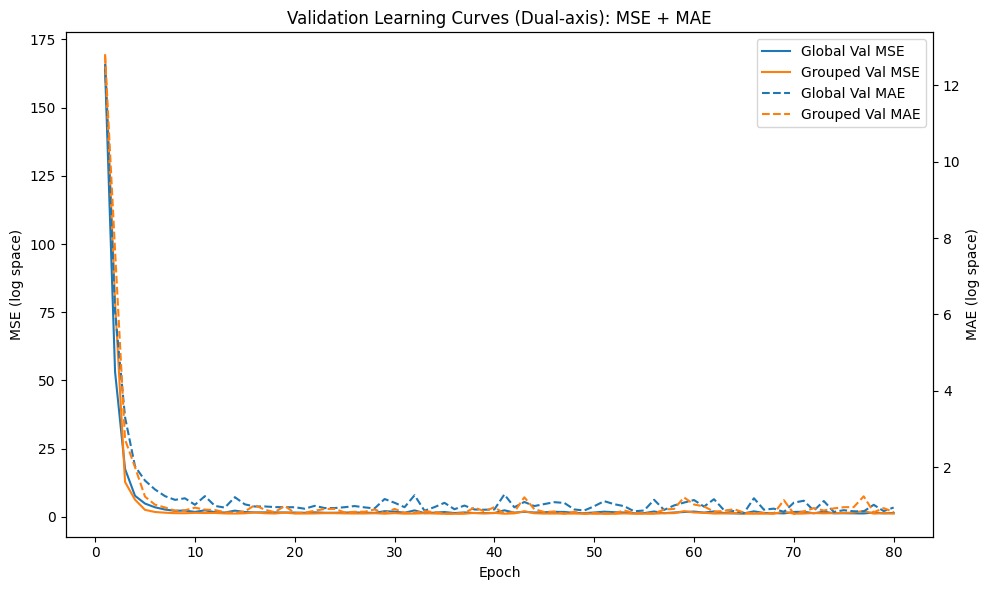

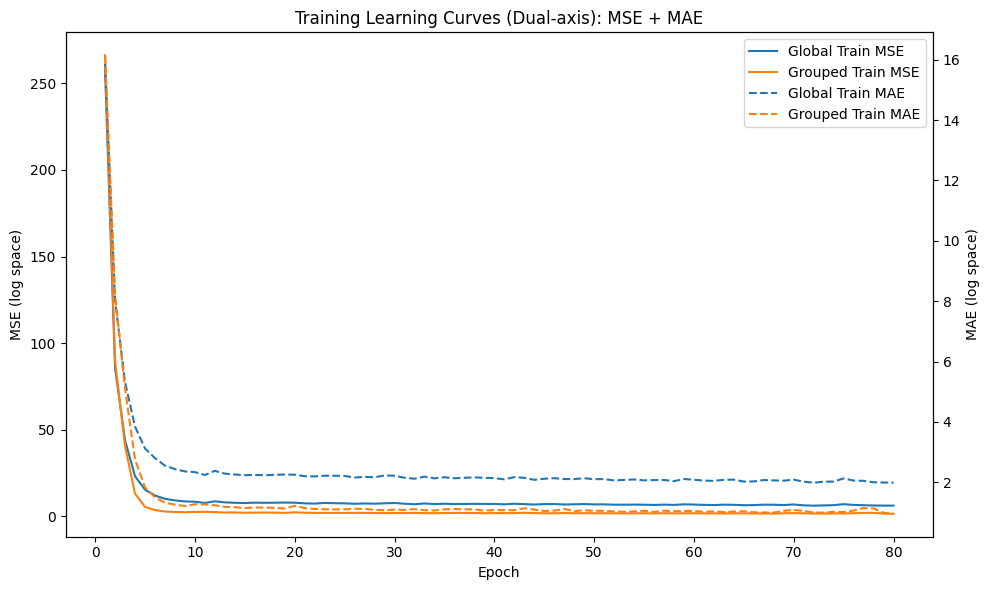

Saved plots: learning_curves_val.png, learning_curves_train.png
                      Model  Final Val MSE  Final Val MAE  \
0        Unified Global MLP       1.418537       0.940399   
1  Hierarchical Grouped MLP       1.157680       0.821333   

   Total Trainable Parameters  Avg Training Time / Epoch (sec)  Best Val MSE  \
0                       63851                         0.127234      1.189355   
1                       69211                         0.149739      1.096559   

   Best Val MAE  
0      0.797164  
1      0.784079  
Saved: research_summary_table.csv


In [14]:
# ============================================
# NEW CELL (place AFTER the training cell above)
# - Saves val/test predictions (as CSV + NPZ)
# - Plots dual-axis learning curves (MSE + MAE)
# - Writes final research summary table
# ============================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---- load best weights (recommended for reporting) ----
global_model.load_state_dict(torch.load("SharedEncoderModel_best.pt", map_location=device))
grouped_model.load_state_dict(torch.load("GroupedEncoderModel_best.pt", map_location=device))

global_model.eval()
grouped_model.eval()

# ---- VAL predictions ----
with torch.no_grad():
    val_pred_global = global_model(X_val_num_t.to(device), X_val_cat_t.to(device)).squeeze(1).cpu().numpy()
    val_pred_group  = grouped_model(X_val_num_t.to(device), X_val_cat_t.to(device)).squeeze(1).cpu().numpy()

np.savez(
    "val_predictions.npz",
    actual_log_gross=y_val,
    global_pred_log_gross=val_pred_global,
    grouped_pred_log_gross=val_pred_group
)

val_df_out = pd.DataFrame({
    "actual_log_gross": y_val,
    "global_pred_log_gross": val_pred_global,
    "grouped_pred_log_gross": val_pred_group,
})
val_df_out.to_csv("val_predictions.csv", index=False)

# ---- TEST predictions ----
X_test_num_t = torch.tensor(X_test_num, dtype=torch.float32)
X_test_cat_t = torch.tensor(X_test_cat, dtype=torch.long)

with torch.no_grad():
    test_pred_global = global_model(X_test_num_t.to(device), X_test_cat_t.to(device)).squeeze(1).cpu().numpy()
    test_pred_group  = grouped_model(X_test_num_t.to(device), X_test_cat_t.to(device)).squeeze(1).cpu().numpy()

np.savez(
    "test_predictions.npz",
    global_pred_log_gross=test_pred_global,
    grouped_pred_log_gross=test_pred_group
)

# If test_df exists in your preprocessing cell, attach identifiers
if "test_df" in globals():
    out = test_df.copy()
    out["global_pred_log_gross"] = test_pred_global
    out["grouped_pred_log_gross"] = test_pred_group
    # optional inverse transform
    out["global_pred_gross"]  = np.expm1(out["global_pred_log_gross"])
    out["grouped_pred_gross"] = np.expm1(out["grouped_pred_log_gross"])
    out.to_csv("test_predictions.csv", index=False)
else:
    pd.DataFrame({
        "global_pred_log_gross": test_pred_global,
        "grouped_pred_log_gross": test_pred_group
    }).to_csv("test_predictions.csv", index=False)

print("Saved: val_predictions.csv/.npz and test_predictions.csv/.npz")

# ---- Dual-axis learning curves (VAL) ----
hist = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# MSE (left axis)
ax1.plot(hist["epoch"], hist["global_val_mse"], label="Global Val MSE")
ax1.plot(hist["epoch"], hist["group_val_mse"],  label="Grouped Val MSE")

# MAE (right axis)
ax2.plot(hist["epoch"], hist["global_val_mae"],  linestyle="--", label="Global Val MAE")
ax2.plot(hist["epoch"], hist["group_val_mae"],   linestyle="--", label="Grouped Val MAE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (log space)")
ax2.set_ylabel("MAE (log space)")
ax1.set_title("Validation Learning Curves (Dual-axis): MSE + MAE")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig("learning_curves_val.png", dpi=150)
plt.show()

# ---- Dual-axis learning curves (TRAIN) ----
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(hist["epoch"], hist["global_train_mse"], label="Global Train MSE")
ax1.plot(hist["epoch"], hist["group_train_mse"],  label="Grouped Train MSE")

ax2.plot(hist["epoch"], hist["global_train_mae"], linestyle="--", label="Global Train MAE")
ax2.plot(hist["epoch"], hist["group_train_mae"],  linestyle="--", label="Grouped Train MAE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (log space)")
ax2.set_ylabel("MAE (log space)")
ax1.set_title("Training Learning Curves (Dual-axis): MSE + MAE")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig("learning_curves_train.png", dpi=150)
plt.show()

print("Saved plots: learning_curves_val.png, learning_curves_train.png")

# ---- Final research table ----
final_row = hist.iloc[-1]

summary = pd.DataFrame([
    {
        "Model": "Unified Global MLP",
        "Final Val MSE": float(final_row["global_val_mse"]),
        "Final Val MAE": float(final_row["global_val_mae"]),
        "Total Trainable Parameters": int(sum(p.numel() for p in global_model.parameters() if p.requires_grad)),
        "Avg Training Time / Epoch (sec)": float(np.mean(hist["global_sec_per_epoch"])),
        "Best Val MSE": float(np.min(hist["global_val_mse"])),
        "Best Val MAE": float(hist.loc[hist["global_val_mse"].idxmin(), "global_val_mae"]),
    },
    {
        "Model": "Hierarchical Grouped MLP",
        "Final Val MSE": float(final_row["group_val_mse"]),
        "Final Val MAE": float(final_row["group_val_mae"]),
        "Total Trainable Parameters": int(sum(p.numel() for p in grouped_model.parameters() if p.requires_grad)),
        "Avg Training Time / Epoch (sec)": float(np.mean(hist["group_sec_per_epoch"])),
        "Best Val MSE": float(np.min(hist["group_val_mse"])),
        "Best Val MAE": float(hist.loc[hist["group_val_mse"].idxmin(), "group_val_mae"]),
    }
])

summary.to_csv("research_summary_table.csv", index=False)
print(summary)
print("Saved: research_summary_table.csv")
